# Phase 1 EDA walkthrough — dax-gen_project

This notebook reproduces the Phase 1 data-curation + EDA work end-to-end, so you can follow along and re-run any piece interactively.

**Goal (see `../spec/spec.md`):** curate three independent sequence-interaction datasets — kept separate, not merged — and characterize each with descriptive EDA. The downstream modeling task is deliberately not decided yet.

**Datasets:**
1. **PPI** — [D-SCRIPT](https://github.com/samsledje/D-SCRIPT) repo-included pairs (human/mouse/fly/yeast/worm/ecoli), excluding COVID/antibody data.
2. **Antibody-antigen** — [AVIDa-hIL6](https://huggingface.co/datasets/COGNANO/AVIDa-hIL6) + [AVIDa-hTNFa](https://huggingface.co/datasets/COGNANO/AVIDa-hTNFa), excluding AVIDa-SARS-CoV-2.
3. **Viral antigenic evolution** — [MLAEP](https://github.com/WHan-alter/MLAEP) repo-included preprocessed SARS-CoV-2 files.

Run this notebook with working directory = the project root (`dax-gen_project/`), using the `eda` conda env (`/hpc/home/emt70/micromamba/envs/eda`). All three datasets must already be fetched into `rawdata/{ppi,avida,mlaep}/` (see `dax-state/runs/phase1-{1,2,3}.md` for exact fetch commands if you need to re-fetch).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)

RAWDATA = Path("../rawdata")  # notebook lives in docs/, project root is one level up
%matplotlib inline

## 1. PPI — D-SCRIPT

Repo-included pair files (`data/pairs/*.tsv`) + sequence files (`data/seqs/*.fasta`) from [samsledje/D-SCRIPT](https://github.com/samsledje/D-SCRIPT), pinned at commit `23cbb0fbbb454d09ee41ff749c1454d8b3c8a4b8`. Clean of COVID/antibody data by construction (pairs are intra-species) — independently verified below.

### 1.1 Load the pair files and normalize labels

The label column is formatted inconsistently across species: `human_{train,test}.tsv` use integer `0`/`1`, while `mouse/fly/yeast/worm/ecoli_test.tsv` use float `0.0`/`1.0`. We cast to a common int type before computing anything.

In [2]:
PAIR_FILES = {
    "human_train": "pairs/human_train.tsv",
    "human_test": "pairs/human_test.tsv",
    "mouse_test": "pairs/mouse_test.tsv",
    "fly_test": "pairs/fly_test.tsv",
    "yeast_test": "pairs/yeast_test.tsv",
    "worm_test": "pairs/worm_test.tsv",
    "ecoli_test": "pairs/ecoli_test.tsv",
}

def read_pairs(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["protein_a", "protein_b", "label"])
    df["label"] = df["label"].astype(float).astype(int)
    return df

ppi_pairs = {name: read_pairs(RAWDATA / "ppi" / rel) for name, rel in PAIR_FILES.items()}
ppi_pairs["human_train"].head()

,protein_a,protein_b,label
0,9606.ENSP00000409077,9606.ENSP00000470819,1
1,9606.ENSP00000263904,9606.ENSP00000472680,1
2,9606.ENSP00000364459,9606.ENSP00000360117,1
3,9606.ENSP00000422403,9606.ENSP00000400591,1
4,9606.ENSP00000388332,9606.ENSP00000346080,1


### 1.2 Positive fraction + row counts per species/split

This is the headline number: what fraction of pairs are labeled interacting (`label == 1`)?

In [3]:
pair_stats = []
for name, df in ppi_pairs.items():
    pair_stats.append({
        "dataset": name,
        "n_rows": len(df),
        "positive_fraction": round(df["label"].mean(), 4),
        "n_unique_proteins": len(set(df["protein_a"]) | set(df["protein_b"])),
        "n_duplicate_rows": int(df.duplicated().sum()),
        "n_missing_values": int(df.isna().sum().sum()),
    })
pair_df = pd.DataFrame(pair_stats)
pair_df

,dataset,n_rows,positive_fraction,n_unique_proteins,n_duplicate_rows,n_missing_values
0,human_train,421792,0.0909,15816,0,0
1,human_test,52725,0.0909,15525,0,0
2,mouse_test,55000,0.0909,37497,0,0
3,fly_test,55000,0.0909,19213,0,0
4,yeast_test,55000,0.0909,5664,0,0
5,worm_test,55000,0.0909,25429,0,0
6,ecoli_test,22000,0.0909,7138,3761,0


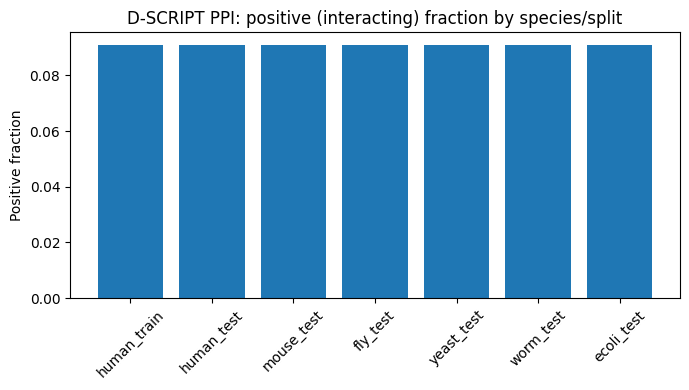

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pair_df["dataset"], pair_df["positive_fraction"])
ax.set_ylabel("Positive fraction")
ax.set_title("D-SCRIPT PPI: positive (interacting) fraction by species/split")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

**Finding:** positive fraction is exactly ~0.0909 (1/11) for *every* species and split — this indicates the D-SCRIPT benchmark uses a fixed 1:10 positive:negative sampling ratio by construction, not an incidental class imbalance. `ecoli_test.tsv` is the only file with duplicate rows (3,761 of 22,000) — worth flagging if using ecoli as a held-out test set.

### 1.3 Sequence length distributions (per species)

In [5]:
SEQ_FILES = {
    "human": "seqs/human.fasta", "mouse": "seqs/mouse.fasta", "fly": "seqs/fly.fasta",
    "yeast": "seqs/yeast.fasta", "worm": "seqs/worm.fasta", "ecoli": "seqs/ecoli.fasta",
}

def read_fasta_seqs(path):
    seqs, cur = [], []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if cur:
                    seqs.append("".join(cur)); cur = []
            else:
                cur.append(line)
        if cur:
            seqs.append("".join(cur))
    return seqs

ppi_seqs = {species: read_fasta_seqs(RAWDATA / "ppi" / rel) for species, rel in SEQ_FILES.items()}

seq_stats = []
for species, seqs in ppi_seqs.items():
    lengths = pd.Series([len(s) for s in seqs])
    seq_stats.append({
        "species": species, "n_sequences": len(seqs),
        "length_min": int(lengths.min()), "length_median": float(lengths.median()),
        "length_mean": round(float(lengths.mean()), 1), "length_max": int(lengths.max()),
        "n_duplicate_seqs": len(seqs) - len(set(seqs)),
    })
seq_df = pd.DataFrame(seq_stats)
seq_df

,species,n_sequences,length_min,length_median,length_mean,length_max,n_duplicate_seqs
0,human,70529,50,406.0,415.5,800,54898
1,mouse,40606,50,370.0,392.4,800,22689
2,fly,19310,50,376.0,388.0,800,7966
3,yeast,5664,50,314.0,341.5,800,73
4,worm,25930,50,335.0,351.8,800,7575
5,ecoli,8848,50,262.0,286.5,799,4436


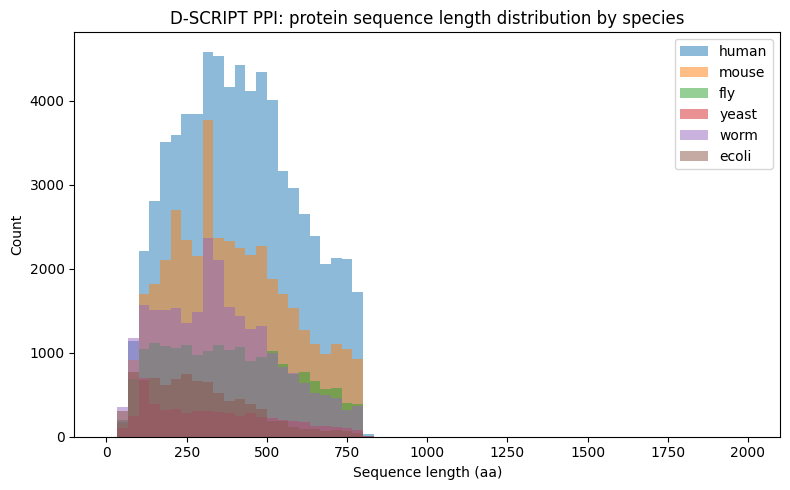

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for species, seqs in ppi_seqs.items():
    ax.hist([len(s) for s in seqs], bins=60, alpha=0.5, label=species, range=(0, 2000))
ax.set_xlabel("Sequence length (aa)")
ax.set_ylabel("Count")
ax.set_title("D-SCRIPT PPI: protein sequence length distribution by species")
ax.legend()
plt.tight_layout()

**Finding:** sequence lengths are hard-capped in [50, 800] aa for every species — a deliberate preprocessing filter in the source data. Large fractions of duplicate sequences (same amino-acid sequence, different protein ID) — e.g. human 78%, mouse 56% — reflect transcript-isoform redundancy in the underlying STRING/Ensembl protein set, not a data error. Worth accounting for if training on this data (isoform duplicates could leak between train/test).

### 1.4 COVID / antibody exclusion — independent verification

The spec requires the PPI dataset to exclude COVID and antibody data. Pairs are intra-species (human-human, mouse-mouse, etc.), so a SARS-CoV-2 protein appearing at all would already be impossible — but we independently verified the human protein set for antibody-gene content via [mygene.info](https://mygene.info)'s batch query API. This re-runs that check live (~16 batched API calls, takes ~20-30s).

In [7]:
import requests, re, time

human_ids = sorted(set(ppi_pairs["human_train"]["protein_a"]) | set(ppi_pairs["human_train"]["protein_b"])
                    | set(ppi_pairs["human_test"]["protein_a"]) | set(ppi_pairs["human_test"]["protein_b"]))
stripped_ids = [i.split(".", 1)[1] for i in human_ids]  # strip "9606." taxon prefix

resolved = {}
for i in range(0, len(stripped_ids), 1000):
    chunk = stripped_ids[i:i+1000]
    r = requests.post("https://mygene.info/v3/query",
                       data={"q": ",".join(chunk), "scopes": "ensembl.protein",
                             "fields": "symbol,name", "species": "human"}, timeout=30)
    for rec in r.json():
        resolved[rec.get("query")] = rec
    time.sleep(0.2)

cov_pattern = re.compile(r"coronavirus|sars-cov|covid", re.I)
chain_pattern = re.compile(r"^(IGH[VDJGMAEC]|IGK[VJC]|IGL[VJC])", re.I)

cov_hits = [(q, r) for q, r in resolved.items() if cov_pattern.search(r.get("name", ""))]
chain_hits = [(q, r.get("symbol"), r.get("name")) for q, r in resolved.items() if chain_pattern.match(r.get("symbol", ""))]

print(f"Resolved {len(resolved)}/{len(stripped_ids)} human protein IDs")
print(f"Coronavirus/COVID hits: {len(cov_hits)}")
print(f"Canonical antibody heavy/light-chain gene hits: {len(chain_hits)}")
for q, sym, name in chain_hits:
    print(" ", q, sym, "-", name)

Resolved 15816/15816 human protein IDs
Coronavirus/COVID hits: 0
Canonical antibody heavy/light-chain gene hits: 1
  ENSP00000474135 IGHV3OR16-17 - immunoglobulin heavy variable 3/OR16-17 (non-functional)


**Result:** 0 coronavirus/COVID hits (confirms impossibility from the intra-species pair structure). One incidental hit for a canonical antibody-variable-region gene (`IGHV3OR16-17`), but it's annotated **non-functional** (an orphan pseudogene, never a productively expressed antibody) and appears only as a negative (non-interacting) label in 33/474,517 pairs — judged not to constitute real antibody-antigen data, and kept in the dataset (human decision).

---
## 2. Antibody-antigen — AVIDa

[AVIDa-hIL6](https://huggingface.co/datasets/COGNANO/AVIDa-hIL6) (573,891 pairs, 31 antigens: WT + 30 IL-6 point mutants) + [AVIDa-hTNFa](https://huggingface.co/datasets/COGNANO/AVIDa-hTNFa) (5,580 pairs, 1 antigen). Both CC-BY-NC-4.0. `AVIDa-SARS-CoV-2` explicitly excluded per spec.

**Note:** column order differs between the two CSVs — hIL6 is `VHH_sequence,label,Ag_label,...`; hTNFa is `VHH_sequence,Ag_label,label,...` (label/Ag_label swapped). We read by column name throughout, not position.

In [8]:
avida_dfs = {
    "hIL6": pd.read_csv(RAWDATA / "avida" / "AVIDa-hIL6.csv"),
    "hTNFa": pd.read_csv(RAWDATA / "avida" / "AVIDa-hTNFa.csv"),
}

overall_stats = []
for name, df in avida_dfs.items():
    lengths = df["VHH_sequence"].str.len()
    overall_stats.append({
        "dataset": name, "n_rows": len(df), "n_antigens": df["Ag_label"].nunique(),
        "positive_fraction": round(df["label"].mean(), 4),
        "n_duplicate_rows": int(df.duplicated().sum()),
        "n_duplicate_vhh_seqs": int(df["VHH_sequence"].duplicated().sum()),
        "n_missing_values": int(df.isna().sum().sum()),
        "vhh_length_min": int(lengths.min()), "vhh_length_median": float(lengths.median()),
        "vhh_length_max": int(lengths.max()),
    })
overall_df = pd.DataFrame(overall_stats)
overall_df

,dataset,n_rows,n_antigens,positive_fraction,n_duplicate_rows,n_duplicate_vhh_seqs,n_missing_values,vhh_length_min,vhh_length_median,vhh_length_max
0,hIL6,573891,31,0.0366,0,535292,0,100,152.0,179
1,hTNFa,5580,1,0.1222,0,3,0,106,152.0,172


**Note on the high "duplicate VHH sequence" count for hIL6** (535,292/573,891 look like duplicates): this is expected, not a data-quality issue. Only 38,599 VHH sequences are actually unique — each is tested against a median of 14 (up to all 31) antigen variants, i.e. one row per (VHH, antigen) combination, by design.

### 2.1 Positive fraction by antigen

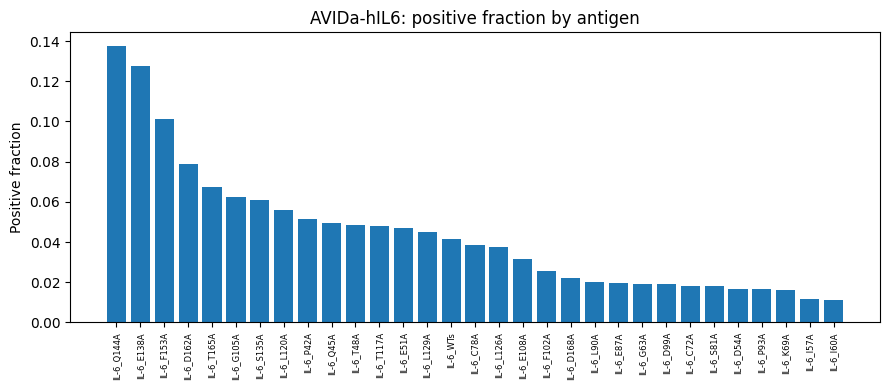

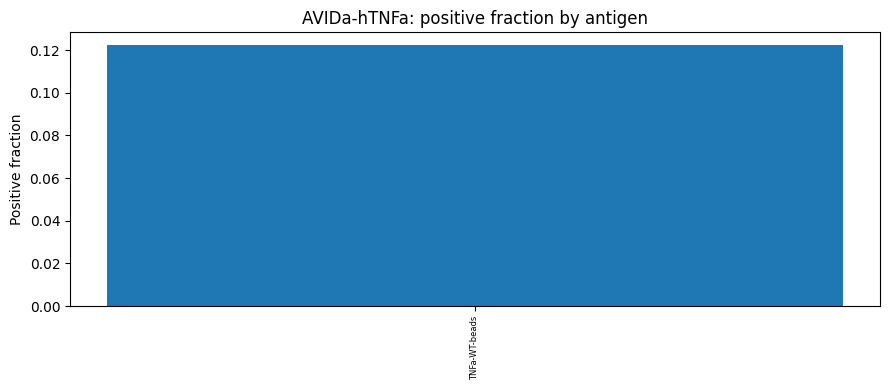

,positive_fraction,n_rows
Ag_label,,
IL-6_Q144A,0.137457,10265
IL-6_E138A,0.127757,10974
IL-6_F153A,0.100968,11469
IL-6_D162A,0.079024,12047
IL-6_T165A,0.067419,14002
IL-6_G105A,0.062319,13832
IL-6_S135A,0.060830,16357
IL-6_L120A,0.056073,13411
IL-6_P42A,0.051441,18040


In [9]:
by_antigen = {}
for name, df in avida_dfs.items():
    by_ag = df.groupby("Ag_label")["label"].agg(["mean", "count"]).rename(
        columns={"mean": "positive_fraction", "count": "n_rows"}
    ).sort_values("positive_fraction", ascending=False)
    by_antigen[name] = by_ag

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(by_ag.index.astype(str), by_ag["positive_fraction"])
    ax.set_ylabel("Positive fraction")
    ax.set_title(f"AVIDa-{name}: positive fraction by antigen")
    ax.tick_params(axis="x", rotation=90, labelsize=6)
    plt.tight_layout()
    plt.show()

by_antigen["hIL6"]

### 2.2 VHH sequence length distributions

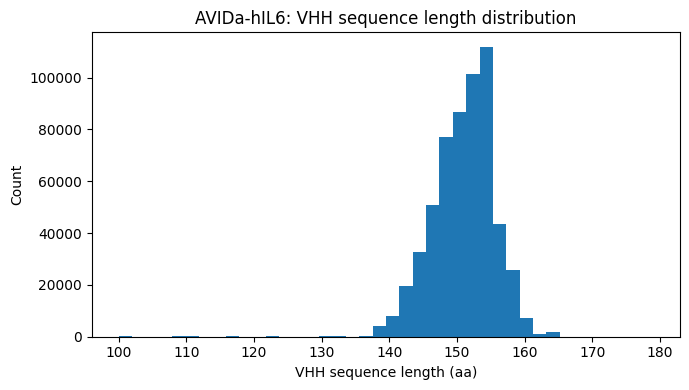

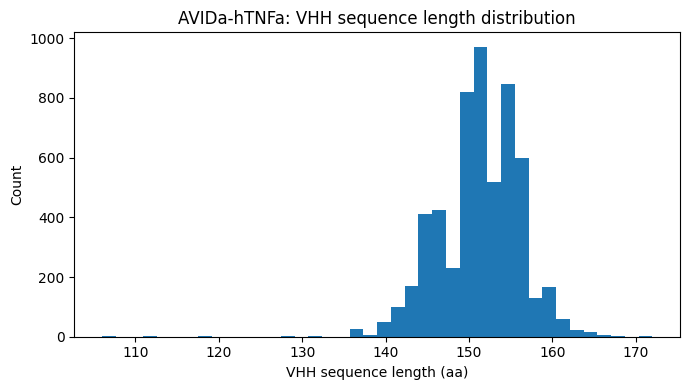

In [10]:
for name, df in avida_dfs.items():
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(df["VHH_sequence"].str.len(), bins=40)
    ax.set_xlabel("VHH sequence length (aa)")
    ax.set_ylabel("Count")
    ax.set_title(f"AVIDa-{name}: VHH sequence length distribution")
    plt.tight_layout()
    plt.show()

### 2.3 SARS-CoV-2 exclusion — independent verification

Confirm no SARS-CoV-2 antigen labels leaked into either file.

In [11]:
for name, df in avida_dfs.items():
    ag_labels = sorted(df["Ag_label"].unique())
    has_covid = any(re.search(r"cov|sars", a, re.I) for a in ag_labels)
    print(f"{name}: {len(ag_labels)} unique Ag_label value(s), SARS-CoV-2/COVID present = {has_covid}")
    print("  ", ag_labels if len(ag_labels) <= 5 else ag_labels[:5] + ["..."])

hIL6: 31 unique Ag_label value(s), SARS-CoV-2/COVID present = False
   ['IL-6_C72A', 'IL-6_C78A', 'IL-6_D162A', 'IL-6_D168A', 'IL-6_D54A', '...']
hTNFa: 1 unique Ag_label value(s), SARS-CoV-2/COVID present = False
   ['TNFa-WT-beads']


---
## 3. Viral antigenic evolution — MLAEP

[MLAEP](https://github.com/WHan-alter/MLAEP) bundles 7 heterogeneous files (not one interaction table like PPI/AVIDa), so "positive fraction" applies specifically where a natural binary label exists — `GMM_covid_info_seq.csv`'s ACE2-binding + per-antibody-clone escape columns. The other files get descriptive stats matching their shape. MLAEP is entirely SARS-CoV-2-focused by design, so the COVID-exclusion rule (which applies to PPI/AVIDa) doesn't apply here.

### 3.1 GMM_covid_info_seq.csv — deep mutational scan (19,132 RBD mutants)

In [12]:
gmm = pd.read_csv(RAWDATA / "mlaep" / "GMM_covid_info_seq.csv", index_col=0)
binary_cols = ["ace2_bind"] + [c for c in gmm.columns if c.startswith("COV2-")]

pos_frac = gmm[binary_cols].mean().round(4).rename("positive_fraction")
print(f"Rows: {len(gmm):,} | Missing values: {int(gmm.isna().sum().sum())} | Duplicate seq rows: {int(gmm['seq'].duplicated().sum())}")
print(f"avg_bind (continuous binding score): mean={gmm['avg_bind'].mean():.3f}, std={gmm['avg_bind'].std():.3f}")
pos_frac.to_frame()

Rows: 19,132 | Missing values: 0 | Duplicate seq rows: 0
avg_bind (continuous binding score): mean=-0.534, std=0.614


,positive_fraction
ace2_bind,0.0805
COV2-2096_400,0.1820
COV2-2832_400,0.0638
COV2-2094_400,0.1045
COV2-2050_400,0.0770
COV2-2677_400,0.0972
COV2-2479_400,0.0486
COV2-2165_400,0.0408
COV2-2499_400,0.1749


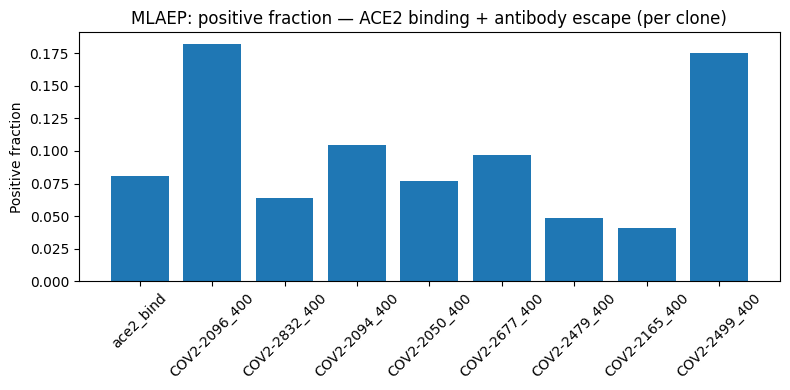

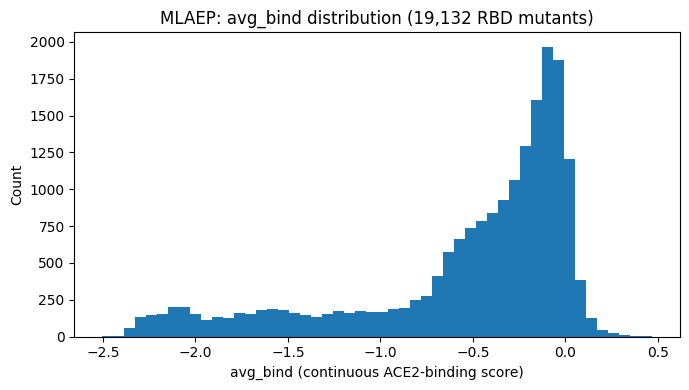

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pos_frac.index, pos_frac.values)
ax.set_ylabel("Positive fraction")
ax.set_title("MLAEP: positive fraction — ACE2 binding + antibody escape (per clone)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gmm["avg_bind"], bins=50)
ax.set_xlabel("avg_bind (continuous ACE2-binding score)")
ax.set_ylabel("Count")
ax.set_title("MLAEP: avg_bind distribution (19,132 RBD mutants)")
plt.tight_layout()
plt.show()

### 3.2 The other 6 files — descriptive stats

`pVNT.csv`/`pVNT_seq.csv` (named high-risk variants + neutralization-reduction), `sars-cov-2_variants_update.csv` (named variant panel), `site_class.csv` (RBD site classification), `Covid19_RBD_seq.txt` (reference sequence), and `merged_all.jsonl` (generic protein structures — no interaction label, so "positive fraction" doesn't apply).

In [14]:
pvnt = pd.read_csv(RAWDATA / "mlaep" / "pVNT.csv")
print(f"pVNT.csv: {len(pvnt)} named variant/mutation combos. Reduction: min={pvnt['Reduction'].min():.2f}, "
      f"median={pvnt['Reduction'].median():.2f}, max={pvnt['Reduction'].max():.2f}, "
      f"negative (enhanced neutralization) entries={int((pvnt['Reduction'] < 0).sum())}")
pvnt

pVNT.csv: 15 named variant/mutation combos. Reduction: min=-9.28, median=34.22, max=97.52, negative (enhanced neutralization) entries=2


,Lineage,WHO,Mutation,Reduction
0,B.1.1.7,Alpha,N501Y,22.92
1,B.1.1.7+E484K,Alpha,E484K;N501Y,74.65
2,B.1.351,Beta,K417N;E484K;N501Y,47.19
3,P.1,Gamma,K417T;E484K;N501Y,47.66
4,B.1.617.2,Delta,K417N;L452R;T478K,49.43
5,B.1.427,Epsilon,L452R,52.57
6,B.1.526,Iota,E484K,10.94
7,B.1.617.1,Kappa,L452R;E484Q,18.34
8,C.37,Lambda,L452Q;F490S,34.22
9,B.1.1.529,Omicron,G339D;S371L;S373P;S375F;K417N;N440K;G446S;S477...,97.52


In [15]:
variants = pd.read_csv(RAWDATA / "mlaep" / "sars-cov-2_variants_update.csv", index_col=0)
print(f"sars-cov-2_variants_update.csv: {len(variants)} entries: {', '.join(variants['name'].tolist())}")

site = pd.read_csv(RAWDATA / "mlaep" / "site_class.csv", index_col=0)
print(f"\nsite_class.csv: {len(site)} sites classified")
print(site["class"].value_counts())
print(f"ACE2-contact flag set for {site['ACE2'].notna().sum()}/{len(site)} sites")

ref = (RAWDATA / "mlaep" / "Covid19_RBD_seq.txt").read_text().strip()
print(f"\nCovid19_RBD_seq.txt: reference RBD sequence, length {len(ref)} aa")

sars-cov-2_variants_update.csv: 7 entries: Alpha, Beta, Gamma, Delta, Omicron, Omicron, wt

site_class.csv: 201 sites classified
class
n      126
4       24
3       23
1       14
2        9
1+2      5
Name: count, dtype: int64
ACE2-contact flag set for 17/201 sites

Covid19_RBD_seq.txt: reference RBD sequence, length 201 aa


In [16]:
import json

lengths = []
with open(RAWDATA / "mlaep" / "merged_all.jsonl") as f:
    for line in f:
        lengths.append(len(json.loads(line)["seq"]))
s = pd.Series(lengths)
print(f"merged_all.jsonl: {len(lengths)} generic protein structures (seq + backbone coords).")
print(f"Sequence length: min={int(s.min())}, median={s.median():.0f}, max={int(s.max())}")
print("No interaction/binding label present — likely the structural-model training set, distinct in kind from the other 6 COVID-specific files.")

merged_all.jsonl: 18 generic protein structures (seq + backbone coords).
Sequence length: min=80, median=110, max=130
No interaction/binding label present — likely the structural-model training set, distinct in kind from the other 6 COVID-specific files.


---
## Summary

| Dataset | Rows | Positive fraction | Key finding |
|---|---|---|---|
| PPI (D-SCRIPT) | 421,792–55,000 per species/split | **~9.09%** (fixed, all species) | 1:10 sampling ratio by construction; lengths capped [50,800]aa; heavy isoform-duplicate redundancy |
| AVIDa-hIL6 | 573,891 | **3.66%** overall (varies by antigen) | 38,599 unique VHH clones × up to 31 antigen variants each |
| AVIDa-hTNFa | 5,580 | **12.22%** (1 antigen) | ~100x smaller than hIL6, 2 subject alpacas |
| MLAEP (`GMM_covid_info_seq.csv`) | 19,132 | **8.05%** ACE2-bind; 4.1–18.2% per antibody clone | Only file among MLAEP's 7 with a natural binary label |

**Exclusions verified independently in this notebook:** PPI has 0 COVID hits + only 1 negligible (non-functional pseudogene) antibody-gene hit; AVIDa has 0 SARS-CoV-2 antigen rows in either file.

**Next step (per `dax-state/session-handoff.md`):** human review of these findings, then Phase 1 close-out (promotion pass, phase-summary run-note), before scoping the downstream modeling task (deliberately deferred in `spec/spec.md`).